# Phase 3: Clustering & Persona Evolution

**Project:** Student Dropout Survival Analysis (Bayes 26D)
**Random seed:** 42 (fixed for every clustering, sampling and jitter call)

## What this notebook does

Phases 1 and 2 asked a *supervised* question: given what we know about a student at a checkpoint, can we predict whether they survive to the next one? This notebook turns to the complementary *unsupervised* question: no answer to predict, just structure to find:

> *What kinds of students enter the course, and which kinds are still there at each checkpoint?*

The approach, building on the methodology document (§8) and the blueprint (§7):

1. **Two axes at entry.** Place every student on an **engagement × performance** plane, using only information available at the first checkpoint.
2. **Personas, two ways.** Group students into a small number of **personas** (recognisable student types), first with an interpretable 2×2 median split, then with data-driven k-means clustering, and check whether the two views agree.
3. **Evolution.** Hold the persona labels fixed and watch the *mix* of personas shift from Cohort 1 through Cohort 4 and on to completion, testing the intuition that the population starts out mixed but narrows, by the final stage, to the students who stuck it out.
4. **Tie-back.** Connect the persona story to Phase 2's classification findings: the easily-predicted "tourist" dropouts of Cohort 1 and the nearly invisible administrative dropouts of Cohort 4.

## Why clustering

Clustering is deliberately open-ended here: the point isn't to test one predefined hypothesis but to let the data's structure speak for itself, with cohort evolution as the more ambitious extension (not the easiest thing to pull off cleanly, but worth attempting given what it could reveal).

**Consumes:** `data/processed/cohort_{1..4}.parquet`, Phase 1's outputs. The raw CSV is never touched.
**Produces:** a persona assignment for every student and persona-mix tables (`outputs/tables/`), plus all figures (`outputs/figures/`).

**Standing guarantees.** No imputation anywhere; a single fixed seed (42); and the survival labels are **never used as clustering inputs**; they are only used *afterwards*, to trace where each persona ends up.

## 1. Imports and global settings

Same single import cell as the previous phases. Chart colours are fixed constants drawn from a colour-blind-safe palette, and each persona keeps the same colour throughout, so a reader can track one group across every figure in the notebook.

In [1]:
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import seaborn as sns

from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score, adjusted_rand_score
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings('ignore')

SEED = 42

# ---- Shared chart chrome ---------------------------------------------------
INK      = '#0b0b0b'   # primary text
INK_2    = '#52514e'   # secondary text
MUTED    = '#898781'   # axis tick labels
GRID     = '#e1e0d9'   # hairline gridlines
BASELINE = '#c3c2b7'   # axis and reference lines
SURFACE  = '#fcfcfb'   # chart background

sns.set_theme(style='whitegrid', rc={
    'figure.facecolor':  SURFACE,
    'axes.facecolor':    SURFACE,
    'savefig.facecolor': SURFACE,
    'grid.color':        GRID,
    'grid.linewidth':    0.8,
    'axes.edgecolor':    BASELINE,
    'axes.labelcolor':   INK_2,
    'text.color':        INK,
    'xtick.color':       MUTED,
    'ytick.color':       MUTED,
    'legend.frameon':    False,
    'savefig.dpi':       150,
    'savefig.bbox':      'tight',
})

# One fixed colour per persona, identical in every figure (colour-blind-safe
# categorical palette; the order is deliberate and never reshuffled).
PERSONA_ORDER = ['Engaged achiever', 'Detached achiever', 'Engaged struggler', 'Disengaged']
PERSONA_COLOR = {
    'Engaged achiever':  '#2a78d6',   # blue
    'Detached achiever': '#1baf7a',   # aqua
    'Engaged struggler': '#eda100',   # yellow
    'Disengaged':        '#008300',   # green
}
# Text colour that stays readable on top of each persona colour
PERSONA_LABEL_INK = {
    'Engaged achiever': 'white', 'Detached achiever': INK,
    'Engaged struggler': INK,    'Disengaged': 'white',
}
# One-hue ordered ramp (light -> dark) for the five exit-depth stages in Section 8
DEPTH_RAMP = ['#86b6ef', '#5598e7', '#2a78d6', '#1c5cab', '#104281']
DEPTH_LABEL_INK = [INK, INK, 'white', 'white', 'white']

print(f'Seed: {SEED}')

Seed: 42


## Paths, constants and a file check

Phase 3 consumes only the four **amortised-engagement** cohort files. The `_noeng` variants exist for Phase 2's with/without-engagement comparison; here the engagement axis is *built from* the amortised values, which is the version I settled on for this analysis (Section 3 comes back to why).

In [2]:
DATA_DIR  = Path('data/processed')
FIG_DIR   = Path('outputs/figures')
TABLE_DIR = Path('outputs/tables')
for d in [FIG_DIR, TABLE_DIR]:
    d.mkdir(parents=True, exist_ok=True)

# Each cohort's binary target (1 = survives to the next checkpoint)
TARGETS = {
    1: 'survives_phase_1',
    2: 'survives_phase_2',
    3: 'survives_phase_3',
    4: 'survives_to_certificate',
}

# Ground-truth cohort sizes from Phase 1 (blueprint section 2.3)
EXPECTED_N = {1: 18_724, 2: 17_512, 3: 15_207, 4: 13_632}

for i in range(1, 5):
    path = DATA_DIR / f'cohort_{i}.parquet'
    assert path.exists(), f'Missing Phase 1 output: {path}'
print('All four cohort files present.')

All four cohort files present.


---
## 2. Load the cohorts and rebuild each student's journey

To track personas across cohorts, we need to know, for every student in Cohort 1, how far they got. Phase 1 computed each student's **lifespan** (the number of cohorts they participated in) but never saved it as a column, and the saved files carry a technical wrinkle: each cohort file's row index was reset to 0, 1, 2, … on write, so there's no student ID column linking the files.

There's still a reliable link, though. Phase 1 built each cohort by *filtering* the previous one, keeping the surviving rows without reordering them, so Cohort 2's rows are exactly Cohort 1's surviving rows, in the same order, and so on down the chain. I don't take this on faith: the next cell proves it, comparing the columns that neighbouring cohorts share, value by value, across every row, and stopping the notebook if a single value disagrees. (The three amortised engagement columns are excluded from this check, since their values are expected to differ between cohorts: the revealed share grows at each stage.) With 13,000–17,000 rows and five to ten compared columns per link, an accidental match isn't realistically possible.

Once the chain is verified, every student gets a stable ID (their row position in Cohort 1), and their lifespan can be read straight off the survival targets:

| Lifespan | Meaning | Read from |
|---|---|---|
| 1 | left after Test 1 | `survives_phase_1 = 0` |
| 2 | left after Test 2 | survived Cohort 1, `survives_phase_2 = 0` |
| 3 | left after Test 3 | survived Cohort 2, `survives_phase_3 = 0` |
| 4 | reached the final stage | survived Cohort 3 |

Lifespan-4 students then split into **completers** (`survives_to_certificate = 1`) and **administrative dropouts**: students who finished the whole course but never received the certificate because the final fee went unpaid. Every count is checked against the ground-truth figures from Phase 1, so the notebook fails loudly if anything has drifted.

In [3]:
cohorts = {i: pd.read_parquet(DATA_DIR / f'cohort_{i}.parquet') for i in range(1, 5)}

# Basic integrity: expected sizes, and Phase 1's no-missing-values guarantee
for i, df in cohorts.items():
    assert len(df) == EXPECTED_N[i], f'Cohort {i}: expected {EXPECTED_N[i]:,} rows, got {len(df):,}'
    assert df.isna().sum().sum() == 0, f'Cohort {i} contains missing values - Phase 1 output is corrupt'

# Excluded from the identity check: amortised values legitimately change
# between cohorts (the revealed share is total / lifespan * cohort number)
ENGAGEMENT_COLS = ['forum Q', 'forum A', 'office hour visits']

def verify_chain_link(parent, child, target_col):
    """Prove that `child`'s rows are exactly `parent`'s surviving rows, in order."""
    shared = [c for c in parent.columns
              if c in child.columns and c not in ENGAGEMENT_COLS]
    survivors = parent.loc[parent[target_col] == 1, shared].reset_index(drop=True)
    matches = survivors.astype(float).equals(child[shared].reset_index(drop=True).astype(float))
    assert matches, f'Row-order link broken between cohorts (checked columns: {shared})'
    return len(shared)

for i in range(1, 4):
    n_cols = verify_chain_link(cohorts[i], cohorts[i + 1], TARGETS[i])
    print(f'Cohort {i} -> Cohort {i + 1}: link verified on {n_cols} shared columns, '
          f'all {len(cohorts[i + 1]):,} rows identical')

Cohort 1 -> Cohort 2: link verified on 5 shared columns, all 17,512 rows identical
Cohort 2 -> Cohort 3: link verified on 8 shared columns, all 15,207 rows identical
Cohort 3 -> Cohort 4: link verified on 10 shared columns, all 13,632 rows identical


In [4]:
# ids[j] = Cohort-1 row positions of the students present in cohort j
ids = {1: np.arange(len(cohorts[1]))}
ids[2] = ids[1][cohorts[1][TARGETS[1]].to_numpy() == 1]
ids[3] = ids[2][cohorts[2][TARGETS[2]].to_numpy() == 1]
ids[4] = ids[3][cohorts[3][TARGETS[3]].to_numpy() == 1]
completed_ids = ids[4][cohorts[4][TARGETS[4]].to_numpy() == 1]

n_students = len(cohorts[1])
lifespan = np.ones(n_students, dtype=int)      # everyone participated in Cohort 1
for j in (2, 3, 4):
    lifespan[ids[j]] = j

OUTCOME_ORDER = ['Left after Test 1', 'Left after Test 2', 'Left after Test 3',
                 'Administrative dropout', 'Completed']
outcome = np.empty(n_students, dtype=object)
outcome[lifespan == 1] = 'Left after Test 1'
outcome[lifespan == 2] = 'Left after Test 2'
outcome[lifespan == 3] = 'Left after Test 3'
outcome[ids[4]]        = 'Administrative dropout'
outcome[completed_ids] = 'Completed'

# The master frame this notebook builds up: one row per entrant
students = pd.DataFrame({'lifespan': lifespan, 'outcome': outcome})
students.index.name = 'student_id'

# ---- Validate against Phase 1's ground truth -------------------------------
assert students['lifespan'].value_counts().sort_index().to_dict() == \
    {1: 1_212, 2: 2_305, 3: 1_575, 4: 13_632}, 'Lifespan counts do not match Phase 1'
assert (students['outcome'] == 'Completed').sum() == 11_177
assert (students['outcome'] == 'Administrative dropout').sum() == 2_455
assert (students['outcome'] != 'Completed').sum() == 7_547   # = all dropout = Y rows

print(f'Journey rebuilt for all {n_students:,} students - every count matches Phase 1.\n')
funnel = students['outcome'].value_counts().reindex(OUTCOME_ORDER)
print(pd.DataFrame({'students': funnel,
                    'share of entrants': (funnel / n_students * 100).round(1).astype(str) + '%'
                    }).to_string())

Journey rebuilt for all 18,724 students - every count matches Phase 1.

                        students share of entrants
outcome                                           
Left after Test 1           1212              6.5%
Left after Test 2           2305             12.3%
Left after Test 3           1575              8.4%
Administrative dropout      2455             13.1%
Completed                  11177             59.7%


### The funnel, recapped

The 18,724 entrants split exactly as Phase 1 established: 1,212 leave after Test 1 (6.5% of entrants), 2,305 after Test 2, and 1,575 after Test 3. Of the 13,632 who finish the course itself, 2,455 are administrative dropouts (completers in behaviour but not on paper) and 11,177 (59.7%) go on to earn the certificate. Everything that follows asks: which kinds of students make up each of those numbers?

---
## 3. The two persona axes: engagement and performance at entry

Every student is placed on a plane with two axes:

- **Engagement**: how much visible effort the student puts into the course.
- **Performance**: how well they score when first tested.

**Why entry data only?** The axes use nothing beyond the first checkpoint: features every student possesses, no matter how early they left. If we instead rebuilt the axes for each cohort from that cohort's richer features, every cohort's personas would be measured on a different yardstick, and "the mix changed" could just mean "the measurement changed." Anchoring on entry features fixes each student's persona the moment Test 1 is done, so any change in the mix can only come from *who survives*, never from a moving definition.

**The engagement axis** combines four signals from Cohort 1:

| Component | What it measures |
|---|---|
| mean of `session 1`, `session 2` | % of the first two lecture recordings watched |
| `forum Q` (Cohort-1 share) | forum questions asked |
| `forum A` (Cohort-1 share) | forum answers given |
| `office hour visits` (Cohort-1 share) | office-hours attendance |

These sit on different scales (percentages versus small counts), so each is first **standardised**: turned into a *z-score* by subtracting the column's mean and dividing by its standard deviation, which centres every component on 0 with the same spread. The axis is then the plain average of the four z-scores. The next cell checks this simple average against the statistically fancier alternative (the first **principal component**, the single direction that captures the most shared variation) to confirm that keeping it simple loses nothing.

**The performance axis** is the Test 1 grade, already ordinal-encoded by Phase 1 (F=0, D=1, C=2, B=3, A=4). For k-means it is standardised like everything else; for the quadrant view we read it as the raw grade.

> **A note on the engagement components.** The three forum/office-hours values are the *amortised* ones Phase 1 produced: each student's course total divided by their lifespan. Two students with identical totals but different lifespans therefore show different Cohort-1 values, with the early leaver showing the larger one. This means the engagement axis is not a perfectly pure entry-time measurement; it mildly reflects how long a student stayed. I've treated this as legitimate behavioural signal rather than a flaw, since amortising is a reasonable way to compare students on unequal footing. Note the **direction** of the effect for what follows: it pushes early leavers *up* the engagement axis, because their whole total appears at once. The headline finding below is that low-engagement students leave early, a pattern this effect works *against*, so if anything the finding is understated, not manufactured.

In [5]:
c1 = cohorts[1]

eng_components = pd.DataFrame({
    'lecture attendance': (c1['session 1'] + c1['session 2']) / 2,
    'forum questions':    c1['forum Q'],
    'forum answers':      c1['forum A'],
    'office hours':       c1['office hour visits'],
})
z = (eng_components - eng_components.mean()) / eng_components.std(ddof=0)

students['engagement_score'] = z.mean(axis=1).to_numpy()
students['test1_grade']      = c1['test 1'].to_numpy()
students['performance_z']    = ((students['test1_grade'] - students['test1_grade'].mean())
                                / students['test1_grade'].std(ddof=0))

print('How the four engagement components correlate:')
print(eng_components.corr().round(2).to_string())

# Robustness check: does the simple average agree with the first principal component?
pca = PCA(n_components=1, random_state=SEED)
pc1 = pca.fit_transform(z.to_numpy())[:, 0]
agreement = abs(np.corrcoef(students['engagement_score'], pc1)[0, 1])
print(f'\nSimple average vs first principal component: |correlation| = {agreement:.3f} '
      f'(PC1 explains {pca.explained_variance_ratio_[0]:.0%} of component variance)')

axis_corr = np.corrcoef(students['engagement_score'], students['test1_grade'])[0, 1]
print(f'Correlation between the two axes (engagement vs Test 1 grade): {axis_corr:+.2f}')

How the four engagement components correlate:
                    lecture attendance  forum questions  forum answers  office hours
lecture attendance                1.00             0.09           0.17         -0.01
forum questions                   0.09             1.00           0.34          0.31
forum answers                     0.17             0.34           1.00          0.41
office hours                     -0.01             0.31           0.41          1.00

Simple average vs first principal component: |correlation| = 0.970 (PC1 explains 44% of component variance)
Correlation between the two axes (engagement vs Test 1 grade): -0.11


### What the axis construction showed

- The three count-based components correlate moderately with each other (0.31–0.41): students who ask questions also tend to answer them and to visit office hours. Lecture attendance is nearly independent of all three (at most 0.17), so the axis blends two genuinely different flavours of effort (watching and participating) rather than repeating one signal four times.
- The simple average agrees with the first principal component almost perfectly (|correlation| ≈ 0.97), so the interpretable version costs nothing.
- The two axes are almost uncorrelated (−0.11): at entry, working hard and scoring well are close to independent, with a faint negative tilt. That tracks a common classroom pattern, where the students asking the most questions are often the ones having difficulties. Two near-independent axes are exactly what a 2×2 needs, so all four quadrants will be well populated.

---
## 4. View 1: the 2×2 quadrant personas

The interpretable approach: split each axis at its **median** (the value with half the students above it and half below) and name the four corners. Two practical notes before the code:

- The engagement score is continuous, so its median split is clean: exactly half the students (9,362) sit on each side.
- The Test 1 grade has only five possible values, so an exact 50/50 split is impossible. The median grade is a C, and we call "high performance" a grade *strictly above* the median: **a B or an A on Test 1** (8,052 students, 43% of entrants). That is also the natural reading of "high performer."

| Persona | Engagement | Test 1 | Plain-English description |
|---|---|---|---|
| **Engaged achiever** | high | B/A | works hard and scores well: the "committed" persona |
| **Detached achiever** | low | B/A | scores well with little visible effort |
| **Engaged struggler** | high | F/D/C | works hard but has not (yet) converted effort into grades |
| **Disengaged** | low | F/D/C | little effort, weak grades: where the "tourists" live |

In [6]:
ENG_MEDIAN   = students['engagement_score'].median()
GRADE_MEDIAN = students['test1_grade'].median()          # = 2.0, a C

high_eng  = students['engagement_score'] > ENG_MEDIAN
high_perf = students['test1_grade'] > GRADE_MEDIAN       # strictly above C = B or A

students['persona_quadrant'] = np.select(
    [high_eng & high_perf, ~high_eng & high_perf, high_eng & ~high_perf],
    ['Engaged achiever', 'Detached achiever', 'Engaged struggler'],
    default='Disengaged',
)

print(f'Engagement median: {ENG_MEDIAN:+.3f}   (above: {high_eng.sum():,} students)')
print(f'Grade median:      {GRADE_MEDIAN:.0f} (C)     (above, i.e. B/A: {high_perf.sum():,} students)\n')

quad_counts = students['persona_quadrant'].value_counts().reindex(PERSONA_ORDER)
assert quad_counts.sum() == n_students
print(pd.DataFrame({'students': quad_counts,
                    'share': (quad_counts / n_students * 100).round(1).astype(str) + '%'
                    }).to_string())

Engagement median: +0.005   (above: 9,362 students)
Grade median:      2 (C)     (above, i.e. B/A: 8,052 students)

                   students  share
persona_quadrant                  
Engaged achiever       3555  19.0%
Detached achiever      4497  24.0%
Engaged struggler      5807  31.0%
Disengaged             4865  26.0%


### Reading the entry mix

The four personas are all well populated, but not equal, and the imbalance is informative rather than a flaw:

- **Engaged struggler 31.0%** and **Disengaged 26.0%** are the two largest groups; **Detached achiever (24.0%)** and **Engaged achiever (19.0%)** follow.
- Exactly 25% each was never possible: the grade split is 43/57 (B/A versus C/D/F), so the two "achiever" personas are structurally smaller.
- The slight negative correlation between the axes also nudges students off the diagonal: high engagement pairs a little more often with lower grades than with higher ones, which is why *Engaged struggler* outnumbers *Engaged achiever* half as much again.

## 5. The persona plane

One scatter plot: every entrant positioned by engagement (x) and Test 1 grade (y), coloured by persona, with the two median split lines drawn in. Because the grade takes only five values, dots would stack into five invisible lines, so a small random vertical **jitter** (±0.18 of a grade step, seeded) spreads them out **for display only**; the underlying data is untouched.

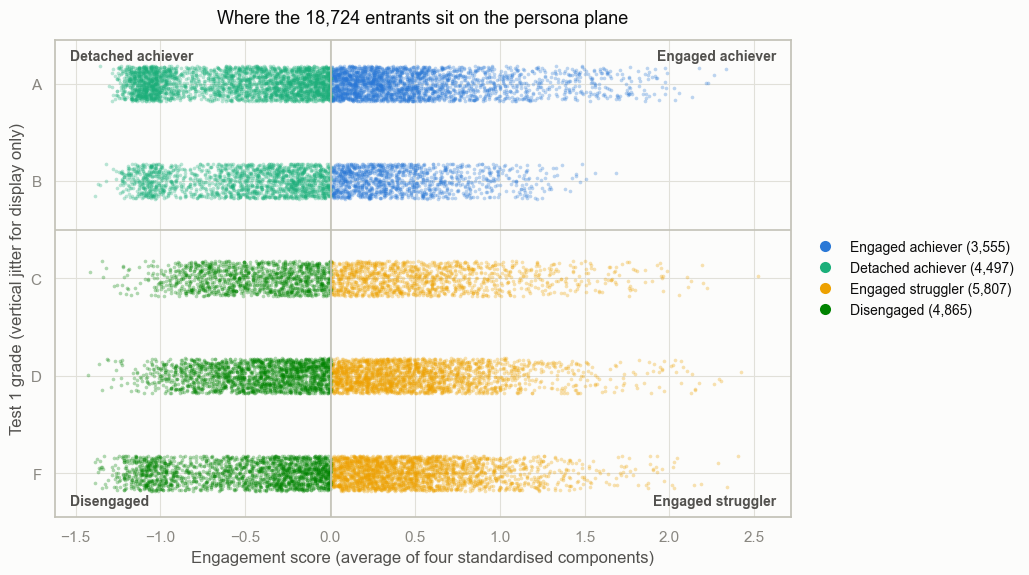

In [7]:
rng = np.random.default_rng(SEED)
y_jitter = students['test1_grade'] + rng.uniform(-0.18, 0.18, n_students)

fig, ax = plt.subplots(figsize=(9.5, 6.2))
for persona in PERSONA_ORDER:
    m = (students['persona_quadrant'] == persona).to_numpy()
    ax.scatter(students['engagement_score'][m], y_jitter[m],
               s=7, alpha=0.30, color=PERSONA_COLOR[persona],
               linewidths=0, rasterized=True)

ax.axvline(ENG_MEDIAN, color=BASELINE, lw=1.2, zorder=3)
ax.axhline(2.5, color=BASELINE, lw=1.2, zorder=3)   # boundary between grade C and B

# Direct quadrant labels (position carries identity; the legend carries colour)
for label, x, y, ha in [('Detached achiever', 0.02, 0.98, 'left'),
                        ('Engaged achiever',  0.98, 0.98, 'right'),
                        ('Disengaged',        0.02, 0.02, 'left'),
                        ('Engaged struggler', 0.98, 0.02, 'right')]:
    ax.text(x, y, label, transform=ax.transAxes, ha=ha,
            va='top' if y > 0.5 else 'bottom', fontsize=10,
            fontweight='bold', color=INK_2)

handles = [Line2D([], [], marker='o', linestyle='', markersize=8,
                  markerfacecolor=PERSONA_COLOR[p], markeredgecolor='none',
                  label=f'{p} ({quad_counts[p]:,})') for p in PERSONA_ORDER]
ax.legend(handles=handles, loc='center left', bbox_to_anchor=(1.01, 0.5), fontsize=10)

ax.set_yticks(range(5))
ax.set_yticklabels(['F', 'D', 'C', 'B', 'A'])
ax.set_ylim(-0.45, 4.45)
ax.set_xlabel('Engagement score (average of four standardised components)')
ax.set_ylabel('Test 1 grade (vertical jitter for display only)')
ax.set_title('Where the 18,724 entrants sit on the persona plane', fontsize=13, pad=12)

fig.savefig(FIG_DIR / 'persona_plane_quadrants.png')
plt.show()

### What the plot shows

The five grade bands are clearly visible as horizontal stripes, and within each band students spread smoothly along the engagement axis: there are **no separated islands**. The population is a continuous cloud, and the quadrant borders are conventions drawn through it, not gaps discovered in it. That observation matters for the next section: if the "true" number of clusters were obvious, k-means would find sharply separated groups; instead we should expect it to *partition* the cloud, much as our median lines just did.

---
## 6. View 2: data-driven personas with k-means

The 2×2 view of Section 4 is built on choices we made: we picked the two axes, and we chose to split them at their medians. That leaves an obvious question open, namely whether the four types are really *in* the data or whether we drew them onto it. **k-means clustering** is the standard way to answer that question, because it looks for groups using only the numerical positions of the students, with no knowledge of what the axes mean. If it finds the same four types on its own, the quadrants stop being a convention and become a finding.

The algorithm works by a simple rule: two students are placed in the same group when they are closer to the same centre point than to any other. It starts by placing k centre points, called **centroids**, at random positions on the plane, where k is the number of groups we want it to find. Every student is then assigned to the nearest centroid using straight-line distance, each centroid moves to the average position of the students that were just assigned to it, and the two steps repeat until the centroids stop moving. The result is a stable division of the plane into k regions, each containing the students who are closer to that region's centre than to any other. The important property is that the method is unsupervised: at no point does it see what a grade value means, what a persona is, or who survives, because the only information it uses is each student's position on the two axes.

Since we have to tell the algorithm how many clusters to look for, two standard diagnostics guide the choice of **k**:

- the **elbow method**, which measures the **inertia** for each candidate k. Inertia is the total squared distance from every student to their own centroid, so it captures how tight the clusters are: low means students sit close to their centre, high means they are spread out. Adding more clusters always lowers inertia, so we do not want the lowest value; we want the point where each new cluster stops buying much extra tightness, which shows up as an "elbow" in the curve.
- the **silhouette score**, a value between −1 and 1 that compares, for each student, the average distance to their own cluster against the average distance to the nearest rival cluster. Positive values mean the student sits closer to their own group than to any other, values near zero mean they sit on a border, and negative values mean they are effectively in the wrong group. Averaged across all students, scores around 0.4 indicate structure that is real but soft, which is typical for behavioural data where people vary continuously rather than falling into sharp categories. (We compute it on a seeded 10,000-student sample, because the score compares every pair of points and 18,724² ≈ 350 million pairs adds minutes of runtime without changing the conclusion.)

Two implementation details are worth being explicit about:

- **Both axes are re-standardised before clustering** so that each contributes equally to the distance calculation. This matters because the averaged engagement score has a smaller spread than the single z-scored performance value, and since k-means reasons purely in distances, the axis with the larger spread would otherwise silently dominate every assignment.
- **The model is fitted once on Cohort 1 and then held fixed.** The centroids are learned from the full entry population and never refitted, which means a student keeps the same cluster label at every stage of the course. This is the same anchoring rule the quadrant view uses, and it exists for the same reason: if the clusters were re-learned at each stage, a change in the persona mix could mean either the students changed (which is what we want to measure) or the definitions moved (which is what we want to rule out). Because every later cohort is a subset of Cohort 1, enforcing this needs no extra code: each surviving student's fixed Cohort-1 label is simply looked up at every later stage.

     inertia  silhouette inertia drop
k                                    
2  21678.715       0.413            -
3  14912.066       0.390          31%
4  10175.459       0.398          32%
5   8267.102       0.403          19%
6   6725.638       0.385          19%
7   5707.449       0.391          15%
8   4972.015       0.416          13%


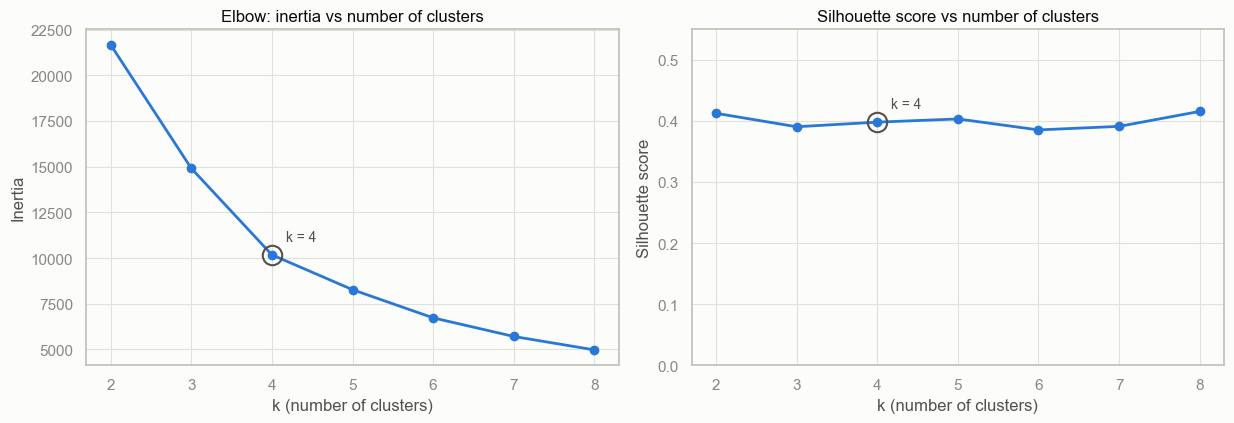

In [8]:
scaler_km = StandardScaler()
X_km = scaler_km.fit_transform(students[['engagement_score', 'performance_z']])

K_RANGE = range(2, 9)
diagnostics = []
for k in K_RANGE:
    km = KMeans(n_clusters=k, n_init=10, random_state=SEED).fit(X_km)
    sil = silhouette_score(X_km, km.labels_, sample_size=10_000, random_state=SEED)
    diagnostics.append({'k': k, 'inertia': km.inertia_, 'silhouette': sil})

diag = pd.DataFrame(diagnostics).set_index('k')
diag['inertia drop'] = (-diag['inertia'].pct_change() * 100).map(
    lambda v: f'{v:.0f}%' if pd.notna(v) else '-')
print(diag.round(3).to_string())

fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.4))
for ax, col, title, ylab in [
        (axes[0], 'inertia',    'Elbow: inertia vs number of clusters', 'Inertia'),
        (axes[1], 'silhouette', 'Silhouette score vs number of clusters', 'Silhouette score')]:
    ax.plot(diag.index, diag[col], color='#2a78d6', lw=2, marker='o', markersize=6)
    ax.plot(4, diag.loc[4, col], marker='o', markersize=14,
            markerfacecolor='none', markeredgecolor=INK_2, markeredgewidth=1.5)
    ax.annotate('k = 4', (4, diag.loc[4, col]), textcoords='offset points',
                xytext=(10, 10), fontsize=10, color=INK_2)
    ax.set_xlabel('k (number of clusters)')
    ax.set_ylabel(ylab)
    ax.set_title(title, fontsize=12)
axes[1].set_ylim(0, 0.55)

fig.tight_layout()
fig.savefig(FIG_DIR / 'kmeans_k_selection.png')
plt.show()

### Choosing k

The two diagnostics point in usefully different directions, and reading them together tells us both which k to pick and how seriously to take the clusters themselves.

- **The elbow points to k ≈ 4.** Inertia falls by roughly 31–32% for each extra cluster up to k = 4, but at k = 5 the gain suddenly halves to 19% and keeps fading from there. In other words, the fourth cluster still buys a substantially tighter description of the data, while the fifth mostly subdivides groups that were already coherent, which is precisely the pattern the elbow heuristic is designed to catch.

- **The silhouette is nearly flat**, sitting between 0.39 and 0.42 across the whole range, with k = 8 and k = 2 marginally on top and k = 4 at 0.398. The fact that no k stands out is itself informative, because it confirms what the scatter plot in Section 5 already showed: this population is a continuous cloud with soft structure rather than a set of well-separated islands, so any small k acts as a *lens* we choose to look through rather than a discovery of the "true" number of student types. The moderate level of the score (around 0.4 rather than near zero) tells us the lens is nonetheless focusing on genuine structure.

We therefore proceed with **k = 4**. It is the elbow's choice on the merits, and the blueprint asks for k = 4 in any case, so that the data-driven view can be compared like-for-like with the four quadrant personas.

In [9]:
km4 = KMeans(n_clusters=4, n_init=10, random_state=SEED).fit(X_km)
raw_labels = km4.labels_

# Centroids back in interpretable units (engagement score, mean Test 1 grade)
centroids = pd.DataFrame(scaler_km.inverse_transform(km4.cluster_centers_),
                         columns=['engagement_score', 'performance_z'])
g_mean = students['test1_grade'].mean()
g_std  = students['test1_grade'].std(ddof=0)
centroids['mean Test 1 grade'] = centroids['performance_z'] * g_std + g_mean
centroids['students'] = pd.Series(raw_labels).value_counts().sort_index()

# Name each cluster by the quadrant its centroid lands in, and give it the
# colour of its quadrant twin so the two views are visually comparable.
QUAD_TO_PERSONA = {(True, True):  'Engaged achiever',  (False, True):  'Detached achiever',
                   (True, False): 'Engaged struggler', (False, False): 'Disengaged'}
km_name, twin_of = {}, {}
for cid in range(4):
    e = centroids.loc[cid, 'engagement_score'] > ENG_MEDIAN
    g = centroids.loc[cid, 'mean Test 1 grade'] > 2.5
    name = f"{'High' if e else 'Low'} eng / {'high' if g else 'low'} grades"
    km_name[cid] = name
    twin_of[name] = QUAD_TO_PERSONA[(e, g)]
assert len(set(km_name.values())) == 4, 'Two centroids landed in the same quadrant - naming needs review'

KM_ORDER     = sorted(twin_of, key=lambda nm: PERSONA_ORDER.index(twin_of[nm]))
KM_COLOR     = {nm: PERSONA_COLOR[twin_of[nm]] for nm in KM_ORDER}
KM_LABEL_INK = {nm: PERSONA_LABEL_INK[twin_of[nm]] for nm in KM_ORDER}
students['persona_kmeans'] = pd.Series(raw_labels).map(km_name).to_numpy()

centroids.index = [km_name[c] for c in centroids.index]
print('The four k-means centroids, in real units:\n')
print(centroids[['engagement_score', 'mean Test 1 grade', 'students']].round(2).to_string())

ari = adjusted_rand_score(students['persona_quadrant'], raw_labels)
print(f'\nAgreement between the two views (adjusted Rand index): {ari:.2f}')
print('\nWho went where (quadrant persona vs k-means cluster):')
print(pd.crosstab(students['persona_quadrant'], students['persona_kmeans'])
        .reindex(index=PERSONA_ORDER, columns=KM_ORDER).to_string())

The four k-means centroids, in real units:

                        engagement_score  mean Test 1 grade  students
Low eng / low grades               -0.41               0.85      5328
High eng / high grades              0.38               3.66      4425
High eng / low grades               0.58               0.80      5266
Low eng / high grades              -0.68               3.59      3705

Agreement between the two views (adjusted Rand index): 0.82

Who went where (quadrant persona vs k-means cluster):
persona_kmeans     High eng / high grades  Low eng / high grades  High eng / low grades  Low eng / low grades
persona_quadrant                                                                                             
Engaged achiever                     3555                      0                      0                     0
Detached achiever                     870                   3627                      0                     0
Engaged struggler                       0         

### The two views agree

Left to its own devices, k-means places its four centroids **one in each quadrant** of the plane (low/low, low/high, high/low and high/high), which means it has rediscovered the supervisor's 2×2 grid from nothing but distances between students. This is the single most reassuring result in the notebook: a method that knew nothing about our median lines ended up drawing essentially the same map.

To put a number on that agreement we use the **adjusted Rand index**, a standard measure of similarity between two groupings, where 0 means the agreement is no better than randomly shuffling labels and 1 means the two groupings are identical. It comes out at **0.82**, which counts as strong agreement. Just as importantly, the disagreements that do exist are exactly where they should be: all of them sit at the borders, because k-means draws slanted boundary lines through the cloud while our medians draw right-angled ones. Concretely, about 870 *Detached achievers* whose engagement was borderline get pulled into the high/high cluster, and about 540 *Engaged strugglers* get pulled into the low/low one, while not a single student is relabelled from one side of the plane to the other.

**Takeaway:** the 2×2 quadrant view is not an arbitrary imposition, because a data-driven method recovers essentially the same four student types on its own. From here on, results are reported for both views side by side, with the quadrant names as the headline (since they are exactly nameable) and k-means serving as confirmation that the story survives a change of method.

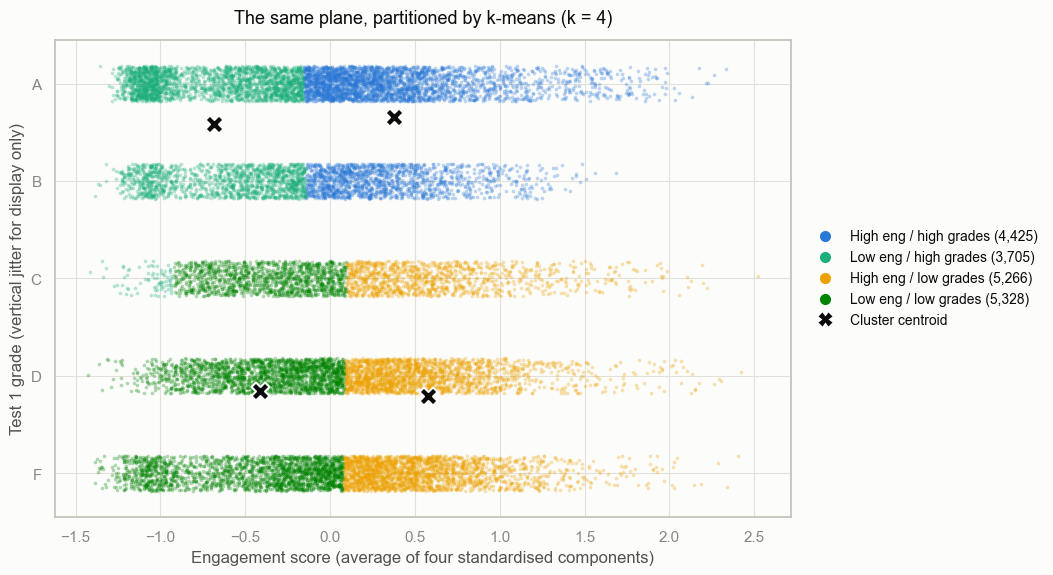

In [10]:
fig, ax = plt.subplots(figsize=(9.5, 6.2))
for name in KM_ORDER:
    m = (students['persona_kmeans'] == name).to_numpy()
    ax.scatter(students['engagement_score'][m], y_jitter[m],
               s=7, alpha=0.30, color=KM_COLOR[name], linewidths=0, rasterized=True)

ax.scatter(centroids['engagement_score'], centroids['mean Test 1 grade'],
           marker='X', s=170, color=INK, edgecolor=SURFACE, linewidth=1.5, zorder=5)

handles = [Line2D([], [], marker='o', linestyle='', markersize=8,
                  markerfacecolor=KM_COLOR[nm], markeredgecolor='none',
                  label=f'{nm} ({centroids.loc[nm, "students"]:,.0f})') for nm in KM_ORDER]
handles.append(Line2D([], [], marker='X', linestyle='', markersize=10,
                      markerfacecolor=INK, markeredgecolor='none', label='Cluster centroid'))
ax.legend(handles=handles, loc='center left', bbox_to_anchor=(1.01, 0.5), fontsize=10)

ax.set_yticks(range(5))
ax.set_yticklabels(['F', 'D', 'C', 'B', 'A'])
ax.set_ylim(-0.45, 4.45)
ax.set_xlabel('Engagement score (average of four standardised components)')
ax.set_ylabel('Test 1 grade (vertical jitter for display only)')
ax.set_title('The same plane, partitioned by k-means (k = 4)', fontsize=13, pad=12)

fig.savefig(FIG_DIR / 'persona_plane_kmeans.png')
plt.show()

---
## 7. The headline analysis: how the persona mix evolves

Everything is now in place for the question the whole notebook has been building towards. The persona labels are **frozen**, meaning they were assigned once, at entry, from entry features alone, so a student who is a Disengaged entrant remains a Disengaged entrant no matter how far they get. For each stage of the course we take the students still present and ask what fraction of them each persona makes up, which turns dropout into a story about *composition*: as students leave, does the surviving population change in kind, or only in size?

| Stage | Who is present | n |
|---|---|---|
| Cohort 1 | everyone | 18,724 |
| Cohort 2 | survived Test 1 (lifespan ≥ 2) | 17,512 |
| Cohort 3 | survived Test 2 (lifespan ≥ 3) | 15,207 |
| Cohort 4 | survived Test 3 (lifespan = 4) | 13,632 |
| **Completed** | earned the certificate | 11,177 |

The fifth stage goes one step beyond the blueprint's Cohort 1 → 4 request, and it is this notebook's window onto Phase 2's Cohort-4 problem. The logic runs as follows: if administrative dropout really is behaviourally invisible, as Phase 2 concluded from its weak Cohort-4 model, then the students removed between Cohort 4 and Completed should look like a random slice of the cohort, and the persona mix should **barely change** across that step. If instead the mix shifts noticeably, some behavioural signature of non-payment exists after all.

The expectation to test comes straight from the methodology document: personas start roughly even, and by the end *"you only have the really committed"*.

In [11]:
STAGES = {'Cohort 1': ids[1], 'Cohort 2': ids[2], 'Cohort 3': ids[3],
          'Cohort 4': ids[4], 'Completed': completed_ids}
STAGE_N = {stage: len(idx) for stage, idx in STAGES.items()}

def persona_mix(col, order):
    """Share (%) of each persona among the students present at each stage."""
    return pd.DataFrame({stage: students[col].iloc[idx].value_counts(normalize=True)
                                 .reindex(order) * 100
                         for stage, idx in STAGES.items()})

mix_quad = persona_mix('persona_quadrant', PERSONA_ORDER)
mix_km   = persona_mix('persona_kmeans', KM_ORDER)

for mix, path in [(mix_quad, 'persona_mix_quadrant.csv'), (mix_km, 'persona_mix_kmeans.csv')]:
    mix.round(2).to_csv(TABLE_DIR / path)

def show_mix(mix, title):
    out = mix.round(1)
    out['change (percentage points)'] = (mix['Completed'] - mix['Cohort 1']).round(1).map('{:+.1f}'.format)
    print(f'{title} - share of each stage (%)\n')
    print(out.to_string())
    print()

show_mix(mix_quad, 'Quadrant personas')
show_mix(mix_km,   'k-means personas (k = 4)')

Quadrant personas - share of each stage (%)

                   Cohort 1  Cohort 2  Cohort 3  Cohort 4  Completed change (percentage points)
persona_quadrant                                                                               
Engaged achiever       19.0      20.2      20.5      22.3       23.1                       +4.2
Detached achiever      24.0      24.7      25.3      22.8       20.9                       -3.1
Engaged struggler      31.0      32.8      33.8      37.2       40.0                       +9.0
Disengaged             26.0      22.2      20.5      17.7       16.0                      -10.0

k-means personas (k = 4) - share of each stage (%)

                        Cohort 1  Cohort 2  Cohort 3  Cohort 4  Completed change (percentage points)
persona_kmeans                                                                                      
High eng / high grades      23.6      25.1      25.8      27.4       28.2                       +4.5
Low eng / high grades  

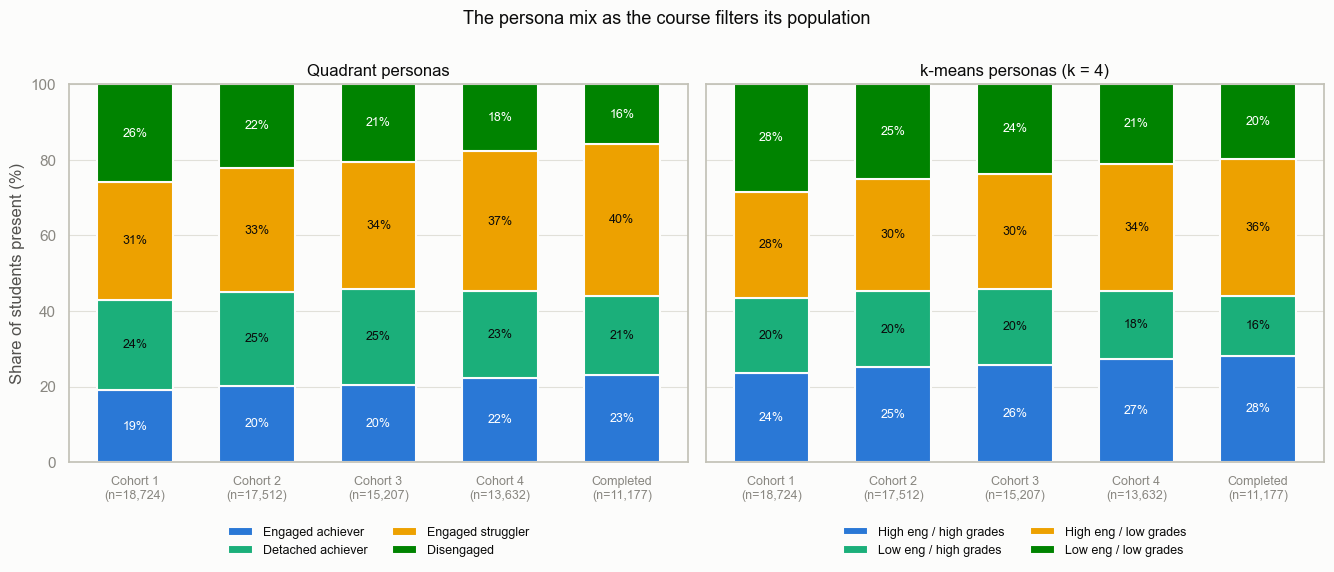

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(13.5, 5.8), sharey=True)
panels = [(axes[0], mix_quad, PERSONA_ORDER, PERSONA_COLOR, PERSONA_LABEL_INK, 'Quadrant personas'),
          (axes[1], mix_km,   KM_ORDER,     KM_COLOR,      KM_LABEL_INK,      'k-means personas (k = 4)')]

x = np.arange(len(STAGES))
for ax, mix, order, colors, label_ink, title in panels:
    bottoms = np.zeros(len(STAGES))
    for p in order:
        vals = mix.loc[p].to_numpy()
        ax.bar(x, vals, 0.62, bottom=bottoms, color=colors[p],
               edgecolor=SURFACE, linewidth=1.5, label=p)
        for xi, (v, b) in enumerate(zip(vals, bottoms)):
            if v >= 6:                                    # label only segments that fit
                ax.text(xi, b + v / 2, f'{v:.0f}%', ha='center', va='center',
                        fontsize=9, color=label_ink[p])
        bottoms += vals
    ax.set_xticks(x)
    ax.set_xticklabels([f'{s}\n(n={STAGE_N[s]:,})' for s in STAGES], fontsize=9)
    ax.set_ylim(0, 100)
    ax.set_title(title, fontsize=12)
    ax.grid(axis='x', visible=False)
    ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.14), ncols=2, fontsize=9)

axes[0].set_ylabel('Share of students present (%)')
fig.suptitle('The persona mix as the course filters its population', fontsize=13, y=1.0)
fig.tight_layout()
fig.savefig(FIG_DIR / 'persona_evolution.png')
plt.show()

### Trajectory view: a complementary read of the same evolution

The stacked bars above answer the question *"what is the mix at each stage?"*, but they make it surprisingly hard to answer the follow-up *"how does one persona's share move across stages?"*, because every band except the bottom one sits on a baseline that itself shifts from bar to bar. The line panel below fixes that by giving each persona its own trajectory, which the eye can follow directly. It uses the same numbers (`mix_quad` / `mix_km`) and the same fixed persona colours, so nothing new is being computed, only re-plotted.

In [ ]:
# One line per persona: reads a single persona's path across the funnel more
# clearly than the stacked band above. Same data, same fixed persona colours.
fig, axes = plt.subplots(1, 2, figsize=(13.5, 5.4), sharey=True)
panels = [(axes[0], mix_quad, PERSONA_ORDER, PERSONA_COLOR, 'Quadrant personas'),
          (axes[1], mix_km,   KM_ORDER,      KM_COLOR,      'k-means personas (k = 4)')]

x = np.arange(len(STAGES))
for ax, mix, order, colors, title in panels:
    for p in order:
        ax.plot(x, mix.loc[p].to_numpy(), marker='o', markersize=6,
                linewidth=2.2, color=colors[p], label=p)
    ax.set_xticks(x)
    ax.set_xticklabels([f'{s}\n(n={STAGE_N[s]:,})' for s in STAGES], fontsize=9)
    ax.set_ylim(0, 100)
    ax.set_title(title, fontsize=12)
    ax.grid(axis='x', visible=False)
    ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.14), ncols=2, fontsize=9)

axes[0].set_ylabel('Share of students present (%)')
fig.suptitle('Persona trajectories as the course filters its population', fontsize=13, y=1.0)
fig.tight_layout()
fig.savefig(FIG_DIR / 'persona_evolution_trajectories.png')
plt.show()

### The story in the numbers

The supervisor's prediction is confirmed, but the data adds one refinement that is worth a paragraph in the report, because it changes what "committed" turns out to mean.

1. **The Disengaged persona shrinks at every single stage**, falling 26.0% → 22.2% → 20.5% → 17.7% → 16.0%. The steepest fall comes at the very first checkpoint, which is exactly the "tourist" exit that Phase 2's Cohort 1 model predicted so easily: students who arrive with little effort and weak grades leave early and keep leaving, so the course continuously distils them out of the population.

2. **The committed personas grow, but "committed" means *engaged*, not *high-scoring*.** The two high-engagement personas together rise from 50.0% of entrants to 63.1% of completers, and the single biggest gainer is the **Engaged struggler**, which climbs from 31.0% to 40.0% (+9.0 points), well ahead of the Engaged achiever (19.0% → 23.1%). Survival, in other words, is selecting students by their effort rather than by their first test result.

3. **The Detached achiever is the twist that makes the refinement necessary.** Its share holds steady through Cohort 3 (24.0% → 25.3%) and then falls away sharply to 20.9% of completers. The interpretation is that good entry grades carry these students past the early checkpoints without difficulty, but the missing engagement catches up with them at the end: Section 8 shows they leave after Test 3 at *ten times* the rate of the engaged personas. On this evidence, **effort at entry predicts staying; early test scores do not.**

4. **The Cohort 4 → Completed step barely moves the mix**, with no persona shifting by more than 2.8 points, even though this step removes 2,455 students, which is 18% of the cohort. This is the answer to the question Section 7 posed: administrative dropout is *almost* persona-blind, which is exactly the unsupervised echo of Phase 2's finding that Cohort 4 resists prediction (best F1 of 0.628 versus 0.97+ everywhere else) because the deciding signal is financial rather than behavioural. The small drift that does exist points the same way as Section 8's table, since the Detached achiever is modestly over-represented among non-payers, and that is consistent with Phase 2's observation that a *subset* of non-payers is visible in behaviour.

5. **The k-means panel tells the same story** with softer borders, as its low/low cluster falls from 28.5% to 19.7% while the high-engagement clusters grow. This matters because it shows the finding does not depend on where exactly the quadrant lines were drawn: redraw the borders with a different method and the same evolution appears.

---
## 8. Where does each entry persona end up?

The mix tables of Section 7 ask "who is present at each stage?", which is the course's point of view. This section flips the question to the student's point of view: **for each entry persona, how deep into the course do its members get?** The table below is *row-normalised*, meaning each persona's row sums to 100% across the five possible outcomes, so a row reads as the full distribution of fates for that kind of student. The chart uses a single blue ramp running light → dark for "left early" → "completed", so that darkness encodes depth and a persona's overall survival can be judged at a glance from how dark its bar is.

In [13]:
depth = (pd.crosstab(students['persona_quadrant'], students['outcome'], normalize='index')
           .reindex(index=PERSONA_ORDER, columns=OUTCOME_ORDER) * 100)

persona_summary = pd.DataFrame({
    'students':                quad_counts,
    'mean lifespan (cohorts)': students.groupby('persona_quadrant')['lifespan']
                                       .mean().reindex(PERSONA_ORDER).round(2),
    'completion rate (%)':     depth['Completed'].round(1),
})

print('Outcome by entry persona (% of that persona)\n')
print(depth.round(1).to_string())
print('\n')
print(persona_summary.to_string())

depth.round(2).to_csv(TABLE_DIR / 'survival_depth_by_persona.csv')

# The tourist archetype, quantified
t1_leavers = students[students['outcome'] == 'Left after Test 1']
dis_share = (t1_leavers['persona_quadrant'] == 'Disengaged').mean()
print(f'\nOf the {len(t1_leavers):,} students who left after Test 1, '
      f'{dis_share:.0%} are Disengaged.')

Outcome by entry persona (% of that persona)

outcome            Left after Test 1  Left after Test 2  Left after Test 3  Administrative dropout  Completed
persona_quadrant                                                                                             
Engaged achiever                 0.5               12.0                1.9                    12.9       72.7
Detached achiever                3.6               11.0               16.2                    17.3       51.9
Engaged struggler                1.1               10.5                1.2                    10.2       77.0
Disengaged                      20.0               15.9               14.6                    12.9       36.7


                   students  mean lifespan (cohorts)  completion rate (%)
persona_quadrant                                                         
Engaged achiever       3555                     3.73                 72.7
Detached achiever      4497                     3.51                 5

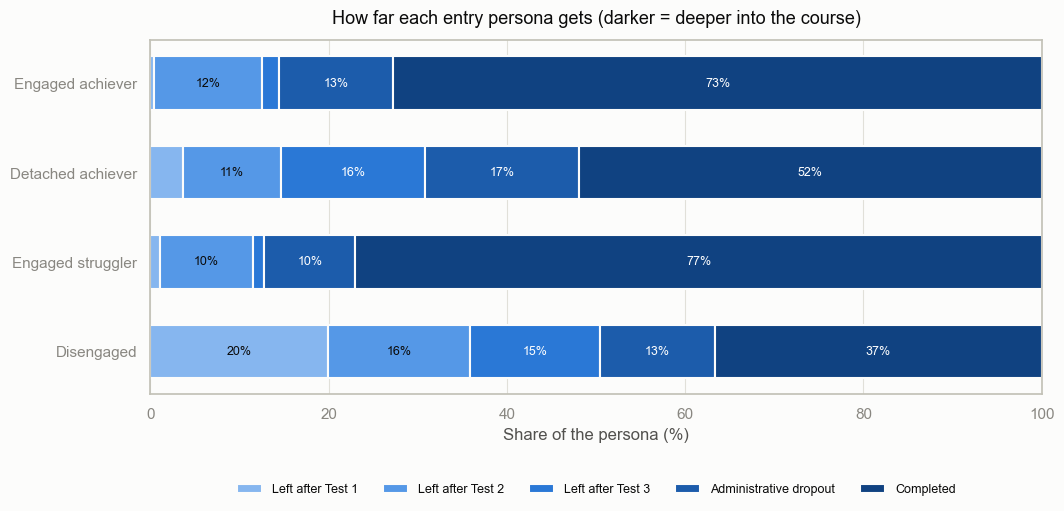

In [14]:
fig, ax = plt.subplots(figsize=(11.5, 4.6))
y = np.arange(len(PERSONA_ORDER))
lefts = np.zeros(len(PERSONA_ORDER))
for stage, color, ink in zip(OUTCOME_ORDER, DEPTH_RAMP, DEPTH_LABEL_INK):
    vals = depth[stage].to_numpy()
    ax.barh(y, vals, 0.6, left=lefts, color=color,
            edgecolor=SURFACE, linewidth=1.5, label=stage)
    for yi, (v, l) in enumerate(zip(vals, lefts)):
        if v >= 5:                                        # label only segments that fit
            ax.text(l + v / 2, yi, f'{v:.0f}%', ha='center', va='center',
                    fontsize=9, color=ink)
    lefts += vals

ax.set_yticks(y)
ax.set_yticklabels(PERSONA_ORDER)
ax.invert_yaxis()
ax.set_xlim(0, 100)
ax.set_xlabel('Share of the persona (%)')
ax.set_title('How far each entry persona gets (darker = deeper into the course)',
             fontsize=13, pad=12)
ax.grid(axis='y', visible=False)
ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.22), ncols=5, fontsize=9)

fig.savefig(FIG_DIR / 'survival_depth_by_persona.png')
plt.show()

### Heatmap variant of the depth table

A compact alternative to the horizontal bars above: the same `depth` table drawn as a heatmap. The bars tell the clearer story for the body of the report, because reading a stacked bar left to right naturally mimics a student moving through the course, but the heatmap packs every persona × exit-stage cell into a small footprint, which makes it the better choice when space is tight. Darker means a larger share of that persona reached that stage.

In [ ]:
# Compact heatmap of the same survival-depth table - a space-efficient alternative
# to the horizontal bars above, intended for the report appendix.
fig, ax = plt.subplots(figsize=(9.5, 4.2))
sns.heatmap(depth.reindex(index=PERSONA_ORDER, columns=OUTCOME_ORDER),
            annot=True, fmt='.0f', cmap='Blues',
            linewidths=1.2, linecolor=SURFACE,
            cbar_kws={'label': '% of persona'}, ax=ax)
ax.set_title('How far each entry persona gets (% of the persona)', fontsize=13, pad=12)
ax.set_xlabel('')
ax.set_ylabel('')
ax.tick_params(axis='y', rotation=0)
ax.tick_params(axis='x', rotation=20)
fig.savefig(FIG_DIR / 'survival_depth_heatmap.png')
plt.show()

### Reading the depth table

- **Disengaged is the at-risk persona, and dramatically so.** Only **36.7% complete**, and **20.0% are already gone at the first checkpoint**, against 0.5% of Engaged achievers, which is a forty-fold difference in early-exit risk between the two corners of the plane. Counting heads makes the concentration even starker: 973 of the 1,212 Test-1 leavers, fully **80%**, come from this one persona. This is the "tourist" archetype quantified, and it explains *why* Phase 2's Cohort 1 model was so accurate (F1 0.976): prediction is easy when the students who leave first are overwhelmingly of one clearly-marked kind.

- **Engaged strugglers finish more often than anyone, at 77.0%**, edging out even the Engaged achievers at 72.7%. That ordering is the notebook's most counterintuitive number, because it means weak first grades combined with real effort is a *better* survival profile than strong first grades without effort. It sits alongside, not against, Phase 2's finding that engagement features carry strong per-student predictive signal, since a group-level tendency and an individual-level prediction are different things.

- **Detached achievers are the quiet risk**, with nearly half (48.1%) never earning the certificate. What makes them quiet is *when* they leave: their exits cluster late, with 16.2% leaving after Test 3, roughly ten times the engaged personas' rate of 1.2–1.9%, and they also carry the highest administrative-dropout share at 17.3%. The pattern reads naturally as talent getting them through the tests while the missing engagement shows up at the end, both as late quitting and as non-payment.

- **"Left after Test 2" is the least persona-driven exit**, varying only from 10.5% to 15.9% across all four personas. Entry-time behaviour evidently says the least about the mid-course checkpoint, which is consistent with Phase 2, where Cohort 2's model leaned on the *newer* Block-B features rather than the entry ones.

---
## 9. Save the persona assignments

The blueprint names two deliverables for this phase: the evolution figures, which were saved above, and a **persona assignment per student**, which this section produces. The file carries one row per entrant, with both persona labels, the two axis values, and the journey information used throughout this notebook, so that the report (or any later analysis, such as Kaplan–Meier curves per persona) can reuse the assignments directly without re-running anything.

In [15]:
assignments = students[['engagement_score', 'test1_grade', 'persona_quadrant',
                        'persona_kmeans', 'lifespan', 'outcome']].round({'engagement_score': 4})
assignments.to_csv(TABLE_DIR / 'persona_assignments.csv')
print(f'Saved {len(assignments):,} rows -> {TABLE_DIR / "persona_assignments.csv"}\n')
assignments.head()

Saved 18,724 rows -> outputs\tables\persona_assignments.csv



,engagement_score,test1_grade,persona_quadrant,persona_kmeans,lifespan,outcome
student_id,,,,,,
0,-0.5958,0,Disengaged,Low eng / low grades,4,Completed
1,-0.5923,0,Disengaged,Low eng / low grades,1,Left after Test 1
2,0.7223,4,Engaged achiever,High eng / high grades,4,Administrative dropout
3,-1.1271,4,Detached achiever,Low eng / high grades,4,Completed
4,1.0343,0,Engaged struggler,High eng / low grades,2,Left after Test 2


---
## Summary: what Phase 3 found

### The personas

Two independent views of the same plane, a hand-drawn 2×2 median split and k-means clustering, agree on four entry personas: **Engaged achiever** (19.0%), **Detached achiever** (24.0%), **Engaged struggler** (31.0%) and **Disengaged** (26.0%). The agreement, measured at 0.82 by the adjusted Rand index, matters beyond being a nice check, because it shows the 2×2 view is not an arbitrary grid: a method that knew nothing about our medians recovered the same structure from distances alone.

### The evolution: prediction confirmed, with a refinement

The predicted story holds, since the population starts mixed and ends dominated by the committed. The refinement is *what "committed" turns out to mean*, because the data says it means engaged rather than high-scoring:

- **Survival selects on engagement, not on entry performance.** The two high-engagement personas grow from 50.0% of entrants to 63.1% of completers, while the Disengaged persona shrinks monotonically from 26.0% to 16.0%.
- **Engaged strugglers are the biggest winners**, rising from 31.0% to 40.0% and completing at the highest rate of all (77.0%), which means effort beats early grades as a survival profile.
- **Detached achievers are the quiet risk**, because they coast through the tests and then quit late or fail to pay, leaving 48.1% of them without the certificate.
- **The tourists are one persona**: 80% of Test-1 leavers are Disengaged, which is precisely why Phase 2 found Cohort 1 so easy to predict.
- **Administrative dropout is nearly persona-blind**, since the Cohort 4 → Completed step barely moves the mix. This is the unsupervised echo of Phase 2's weak Cohort 4 result (F1 0.628), whose deciding signal is financial rather than behavioural.

### What an instructor could do with this

1. **Intervene before Test 1, and target engagement, not grades.** The heavy losses at the first checkpoint are concentrated in one visible persona, and since engaged strugglers mostly make it, the flag worth acting on is low early engagement rather than a weak first test.
2. **Check in on quiet high-scorers late in the course.** Good grades mask a late-exit and non-payment risk that only materialises after Test 3, so the students who look safest mid-course deserve a second look near the end.

### Limitations, stated honestly

- The axes are two coarse summaries of student behaviour, so the personas should be read as useful lenses rather than natural kinds. The silhouette score of roughly 0.4 confirms that the population is a continuous cloud, and the borders drawn through it are conventions rather than gaps found in the data.
- The engagement axis is built from *amortised* Cohort-1 values, meaning each student's total forum and office-hour activity is spread evenly over the cohorts they participated in. This construction mildly encodes lifespan into the axis, since a student who survived longer has their total divided across more cohorts. The direction of that effect *dampens* the headline finding rather than inflating it (longer-surviving students appear slightly *less* engaged at entry than they truly were), but it should still be flagged when the result is reported.
- The persona borders depend on choices made in this analysis: the median splits are relative to this particular population, and k-means with a different random seed or a different k would redraw the boundaries. The seed is fixed at 42 throughout, and k = 4 is supported by both the elbow and the agreement with the quadrant view, but the caveat stands.
- Everything here is **descriptive, not causal**. Engagement at entry is strongly associated with survival, but this analysis cannot say that forcing a disengaged student to participate more would cause them to complete the course.

